### "study.ipynb" dosyasında datada yapılması gereken değişiklikleri buldum ve burada kullanacağım modifiye edilmiş dataseti hazırlayacağım

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
data_path = "/home/tahas44/Desktop/NYC-Taxi/datas/yellow_tripdata_2015-01.parquet"
df = pd.read_parquet(data_path)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,1,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,N,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,None,None
12741031,1,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,N,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,None,None
12741032,1,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,N,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,None,None
12741033,1,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,N,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,None,None


In [3]:
df["duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60 # geçen süre (dk)

In [4]:
garbage_rows = df[(df["fare_amount"] < 0) | (df["fare_amount"] > 100) |
                  (df["extra"] < 0) | (df["extra"] > 1) |
                  (df["mta_tax"] < 0) |
                  (df["tip_amount"] < 0) | (df["tip_amount"] >= 18) |
                  (df["tolls_amount"] < 0) | (df["tolls_amount"] > 12) |
                  (df["duration"] <= 0) | (df["duration"] >= 102) |
                  (df["passenger_count"] <= 0) | (df["passenger_count"] > 6) |
                  (df["trip_distance"] <= 0) | (df["trip_distance"] > 24) |
                  (df["RatecodeID"] == 99)].index

df.drop(index=garbage_rows, inplace=True)

In [5]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,duration
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None,5.250000
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None,5.933333
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None,14.783333
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None,7.900000
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None,6.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,1,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,N,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,None,None,9.300000
12741031,1,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,N,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,None,None,6.816667
12741032,1,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,N,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,None,None,21.483333
12741033,1,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,N,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,None,None,46.700000


In [6]:
(1 / 120) * 100 # study.ipynb de çalışılan data cleaning sonucu

0.8333333333333334

In [7]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'duration'],
      dtype='object')

In [8]:
df.drop(columns=["VendorID", "congestion_surcharge", "airport_fee",], inplace=True)

In [9]:
df.drop(columns=["store_and_fwd_flag"], inplace=True)

In [10]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000


In [11]:
df["payment_type"].min()

np.int64(1)

In [12]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'duration'],
      dtype='object')

In [13]:
df.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
duration                 0
dtype: int64

In [14]:
df[df.duplicated()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
495485,2015-01-02 12:45:27,2015-01-02 12:57:28,1,2.30,1,186,142,2,10.5,0.0,0.5,0.0,0.0,0.0,11.3,12.016667
7004578,2015-01-17 18:09:40,2015-01-17 18:21:25,2,1.56,1,264,264,1,9.0,0.0,0.5,4.0,0.0,0.3,13.8,11.750000


In [15]:
df.drop_duplicates(inplace=True)    # 2 tane duplicate satır gitti!

In [16]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000


### Step3 Feature Understanding

In [17]:
df["total_amount"].value_counts()   # number of the unique values

total_amount
6.80      413435
7.30      381416
8.30      380168
7.80      372513
9.80      366290
           ...  
31.94          1
4.27           1
113.80         1
82.72          1
84.07          1
Name: count, Length: 7384, dtype: int64

In [18]:
df["total_amount"].value_counts().head()  # number of the unique values and head

total_amount
6.8    413435
7.3    381416
8.3    380168
7.8    372513
9.8    366290
Name: count, dtype: int64

In [19]:
df["total_amount"].value_counts().tail()

total_amount
31.94     1
4.27      1
113.80    1
82.72     1
84.07     1
Name: count, dtype: int64

<Axes: xlabel='total_amount'>

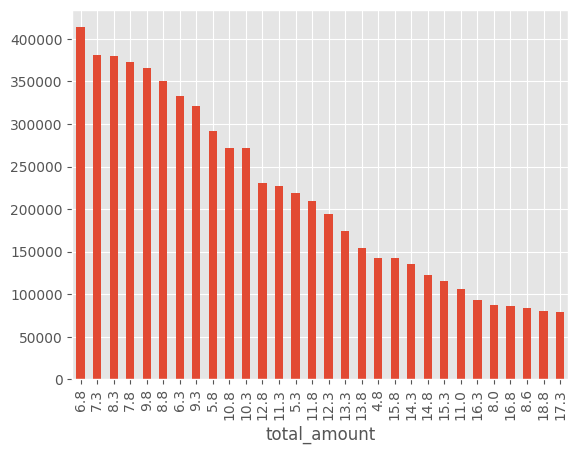

In [20]:
df["total_amount"].value_counts().head(30).plot(kind="bar")

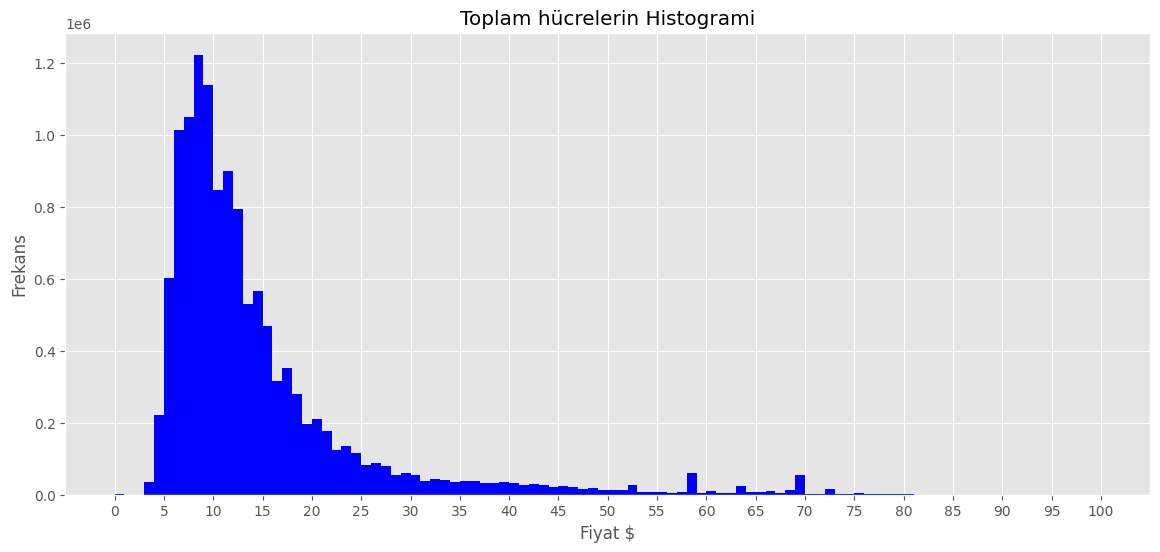

In [21]:
# Histogram ile oynama
plt.figure(figsize=(14,6))

df[df["total_amount"] <= 100]["total_amount"].plot(
    kind="hist", 
    bins=100, 
    color="blue"
)

plt.xticks(range(0, 105, 5))

plt.title("Toplam hücrelerin Histogrami")
plt.xlabel("Fiyat $")
plt.ylabel("Frekans")
plt.show()

### Step 4: Feature Relationships 
- Bu kısımda elimizdeki verilerin birbiri ile olan ilişkisini incelemeliyim

In [22]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000


In [23]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'duration'],
      dtype='object')

### 4.1: passenger_count - total_amount ilişkisi
- Bir grafik çizerek bu ikisi arasındaki ilişkiyi çıkarmalıyım

Bu ilişkiyi çizerken "scatter" grafiği kullanmak istedim lakin 12M veri için RAM yetmedi. İkinci yöntem "hexbin":

<Axes: title={'center': 'Yolcu Sayısı ve Fiyat İlişkisi (Tüm Veri - Hexbin)'}, xlabel='passenger_count', ylabel='total_amount'>

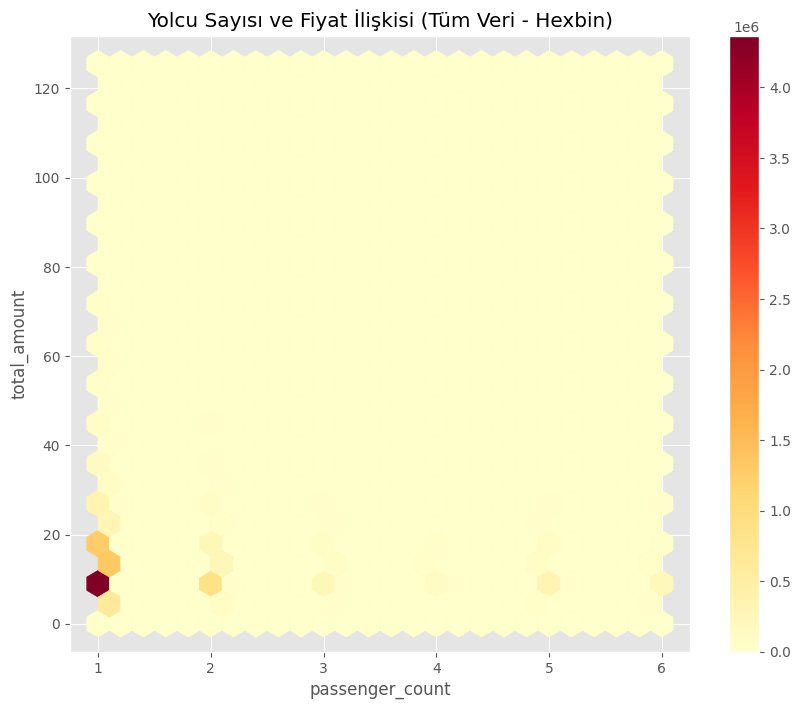

In [ ]:
# Tüm veriyi bal peteği mantığıyla saniyeler içinde çizdir
df.plot(
    kind="hexbin", 
    x="passenger_count", 
    y="total_amount", 
    gridsize=25, 
    cmap="YlOrRd",
    figsize=(10, 8),
    title="Yolcu Sayısı ve Fiyat İlişkisi (Tüm Veri - Hexbin)"
)

Çıkarım: Yolcu sayısı, toplam fiyatı etkilemiyor. Yolcu sayısı artmasına rağmen, yoğunluk yatay kalmış. Fiyat için model eğitirken yolcu sayısına gerek yok.

### 4.2 : trip_distance and total_amount

<Axes: title={'center': 'Gidilen yol ve para ilişkisi'}, xlabel='trip_distance', ylabel='total_amount'>

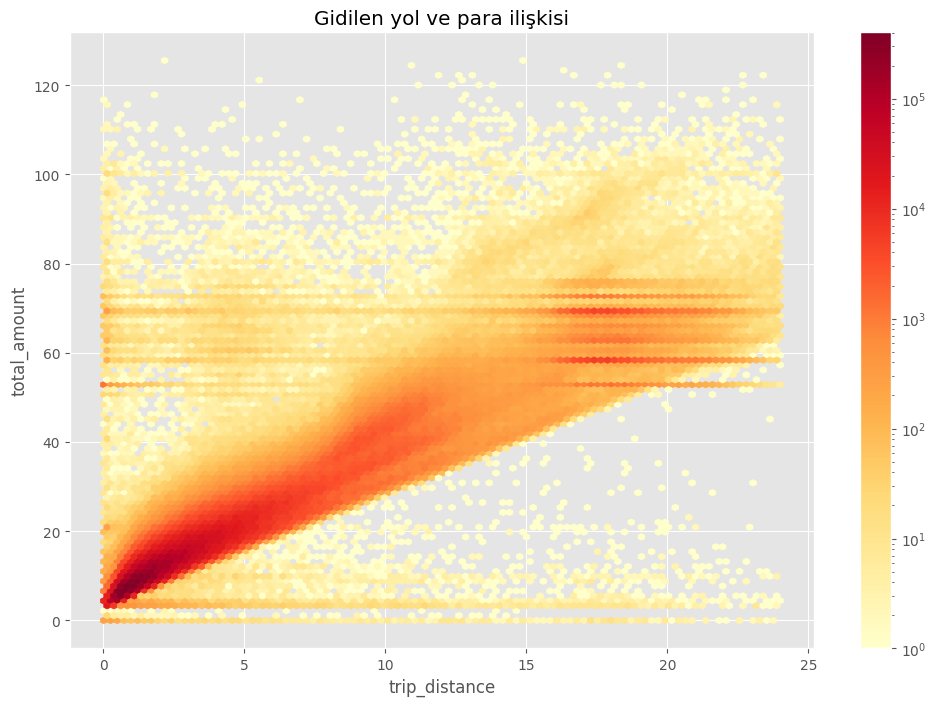

In [ ]:
df.plot(
    kind="hexbin", 
    x="trip_distance", 
    y="total_amount", 
    grid=50,
    bins="log",     # veri sadece bir yere biriktiğinde okunurluk azalır. "log" parametresi bunu engeller
    cmap="YlOrRd", 
    figsize=(12,8),
    title="Gidilen yol ve para ilişkisi"
)

In [41]:
df[df["total_amount"] == 52]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
98257,2015-01-01 03:08:34,2015-01-01 03:29:18,3,4.80,5,158,17,1,39.7,0.0,0.0,12.00,0.00,0.0,52.0,20.733333
151862,2015-01-01 08:13:41,2015-01-01 08:34:06,1,14.50,1,179,257,1,39.2,0.0,0.5,12.00,0.00,0.0,52.0,20.416667
219909,2015-01-01 13:15:44,2015-01-01 13:50:15,1,15.70,1,138,91,1,45.5,0.0,0.5,5.70,0.00,0.0,52.0,34.516667
222601,2015-01-01 14:49:51,2015-01-01 15:31:11,1,14.60,1,132,181,1,44.2,0.0,0.5,7.00,0.00,0.0,52.0,41.333333
246766,2015-01-01 15:26:21,2015-01-01 15:56:20,1,16.60,1,132,80,1,46.2,0.0,0.5,5.00,0.00,0.0,52.0,29.983333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10756108,2015-01-26 16:48:03,2015-01-26 18:07:08,1,7.60,1,90,225,1,44.0,1.0,0.5,6.20,0.00,0.3,52.0,79.083333
11325075,2015-01-29 02:22:19,2015-01-29 02:53:31,1,16.39,1,232,81,1,47.5,0.5,0.5,3.20,0.00,0.3,52.0,31.200000
11367757,2015-01-29 07:23:48,2015-01-29 07:59:47,1,14.32,1,149,233,1,42.5,0.0,0.5,3.37,5.33,0.3,52.0,35.983333
11665668,2015-01-29 21:08:49,2015-01-29 21:47:10,1,16.19,1,88,9,1,47.0,0.5,0.5,3.70,0.00,0.3,52.0,38.350000


!!! 52 doları civarı turuncu çizgi havalimanı ücretini gösteriyor. Havalimanı sabit ücrerti 52 dolar.

Çıkarım: beklenildiği üzere mesafe arttıkça fiyat da arttı!

### 4.3: Duration

<Axes: title={'center': 'The relationship between elapsed time and price'}, xlabel='duration', ylabel='total_amount'>

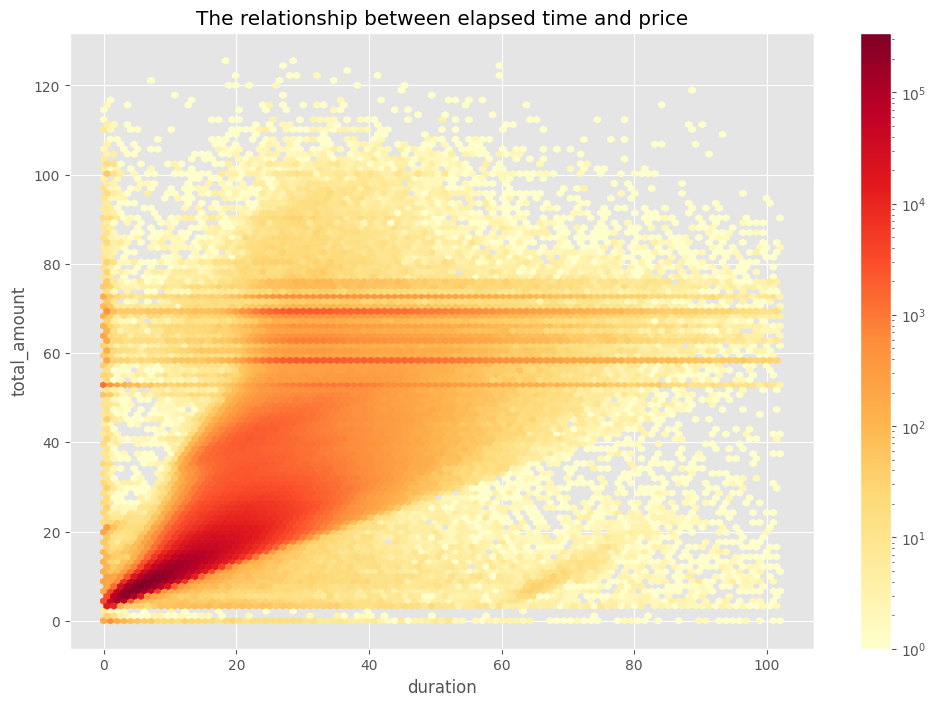

In [43]:
df.plot(
    kind="hexbin", 
    x="duration",
    y="total_amount", 
    figsize=(12,8), 
    bins="log",
    grid=50,
    cmap="YlOrRd", 
    title="The relationship between elapsed time and price"
)

Çıkarım: "Mesafe"de olduğu kadar linear bir grafik sağlayamasak da geçen süre ve para arasında bir ilişki olduğu doğrudur. Model eğitiminde kullanılabilir. 52 dolar yine sabit çünkü havalimanına giderken yol ve zamandan bağımsız ücret ödenir. Zaman sabitken fiyatların değişmesi trafikyen kaynaklı olabilir, belki bunun için saat ve para ilişkisne bakılmalı?